# NB02 — Phase 1A Null Model Construction

**Project**: Gene Function Ecological Agora — Innovation Atlas Across the Bacterial Tree  
**Phase**: 1A — Pilot null model calibration  
**Purpose**: Build the producer and consumer null models specified in `RESEARCH_PLAN.md` (`Null Model Specification` section), calibrate them on the Phase 1A pilot extract, and materialize the null-model lookup tables for NB03 (pilot atlas) and NB04 (phase gate).

## Inputs (from NB01)

- `data/p1a_pilot_species.tsv` — 1,000 species × 22 cols (taxonomy, quality, annotation density)
- `data/p1a_pilot_uniref50.tsv` — 1,000 UniRef50s × 15 cols (COG/KEGG/IPR/GO + control_class)
- `data/p1a_pilot_extract.parquet` — 4,084 (species, UniRef50) presence rows with paralog counts

## Outputs

- `data/p1a_null_producer_lookup.parquet` — per-(species, prevalence-bin) cohort mean / std of paralog count, for closed-form producer-null z-scoring at NB03
- `data/p1a_null_consumer_lookup.parquet` — per-UniRef50 observed phylum-dispersion metric + null mean / std from P=1000 permutations
- `data/p1a_null_diagnostics.json` — null-model calibration diagnostics: cohort sizes, null distribution shapes, sanity tests
- `figures/p1a_null_producer_distribution.png` — producer-null cohort distribution per prevalence bin
- `figures/p1a_null_consumer_distribution.png` — consumer-null permutation distribution shapes
- `figures/p1a_paralog_count_distribution.png` — raw paralog count distribution by control class

## Method overview

### Producer null — clade-matched neutral-family null (closed form)

For each species C and each UniRef50 F present in C:

1. Compute prevalence(F) = fraction of pilot species containing F
2. Bin F into one of 10 prevalence quantiles
3. The producer null cohort for (C, F) is the set of paralog counts of all other UniRef50s present in C in the same prevalence bin
4. Producer z-score is computed at NB03 as `(paralog(C, F) - cohort_mean(C, prev_bin)) / cohort_std(C, prev_bin)`

Closed-form per-bin moments are computed once here and looked up in NB03 — much faster than per-(C, F) permutation sampling.

### Consumer null — phyletic-distribution permutation null (P=1000)

For each UniRef50 F:

1. Build the species presence vector across the 1,000 pilot species
2. Compute observed metric: **phylum_dispersion(F) = n_phyla_with_F / n_species_with_F** (range 0–1; 0 = clumped within phylum, 1 = maximally dispersed)
3. Permute the presence vector P=1000 times preserving column sum (number of species F is in)
4. Compute null distribution of phylum_dispersion under permutation
5. Consumer z-score is `(observed - null_mean) / null_std`. Positive z = more dispersed than null (HGT signal); negative z = more clumped than null (vertical inheritance signal).

### Paralog count fallback (per user decision after NB01)

~20% of (species, UniRef50) presence pairs in the pilot extract have `n_uniref90_present = 0` — UniRef50 is mapped but UniRef90 is not. **Option (a) from NB01 followup**: use `n_gene_clusters` as paralog proxy when UniRef90 is missing:

```python
paralog_count = n_uniref90_present if n_uniref90_present >= 1 else n_gene_clusters
```

This preserves all 4,084 presence rows. NB03 reports producer-score sensitivity to this choice as a robustness check.

## Setup

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/home/aparkin/BERIL-research-observatory/projects/gene_function_ecological_agora")
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

N_PERMUTATIONS = 1000
N_PREVALENCE_BINS = 10

diagnostics = {
    "seed": RNG_SEED,
    "n_permutations": N_PERMUTATIONS,
    "n_prevalence_bins": N_PREVALENCE_BINS,
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
}
print(json.dumps(diagnostics, indent=2))

{
  "seed": 42,
  "n_permutations": 1000,
  "n_prevalence_bins": 10,
  "timestamp_utc": "2026-04-26T21:40:43Z"
}


## Stage 1 — Load pilot data + build matrices

In [2]:
species_df = pd.read_csv(DATA_DIR / "p1a_pilot_species.tsv", sep="\t")
uniref_df = pd.read_csv(DATA_DIR / "p1a_pilot_uniref50.tsv", sep="\t")
extract_df = pd.read_parquet(DATA_DIR / "p1a_pilot_extract.parquet")

print(f"Species: {species_df.shape}")
print(f"UniRef50: {uniref_df.shape}")
print(f"Extract:  {extract_df.shape}")

# Apply paralog-count fallback (option (a) from NB01 follow-up)
extract_df["paralog_count"] = np.where(
    extract_df["n_uniref90_present"] >= 1,
    extract_df["n_uniref90_present"],
    extract_df["n_gene_clusters"],
).astype(int)

# Stat: how many rows used the fallback?
n_fallback = int((extract_df["n_uniref90_present"] < 1).sum())
diagnostics["n_fallback_paralog_rows"] = n_fallback
diagnostics["frac_fallback_paralog_rows"] = n_fallback / len(extract_df)
print(f"Fallback paralog count used for {n_fallback}/{len(extract_df)} rows ({100*n_fallback/len(extract_df):.1f}%)")

print(f"\nParalog count distribution:")
print(extract_df["paralog_count"].describe())

Species: (1000, 22)
UniRef50: (1200, 15)
Extract:  (6638, 5)
Fallback paralog count used for 1170/6638 rows (17.6%)

Paralog count distribution:
count    6638.000000
mean        1.114191
std         0.506317
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        11.000000
Name: paralog_count, dtype: float64


In [3]:
# Build species × UniRef paralog matrix (long → wide)
# We'll keep everything in pandas; 1000 × 1000 = 1M cells, easily manageable.
species_ids = species_df["gtdb_species_clade_id"].tolist()
uniref_ids = uniref_df["uniref50_id"].tolist()

species_idx = {s: i for i, s in enumerate(species_ids)}
uniref_idx = {u: i for i, u in enumerate(uniref_ids)}

N_SPECIES = len(species_ids)
N_UNIREFS = len(uniref_ids)

# Sparse fill — extract has 4,084 presences; matrix has 1,000,000 cells, mostly zero
M_paralog = np.zeros((N_SPECIES, N_UNIREFS), dtype=np.int32)
M_present = np.zeros((N_SPECIES, N_UNIREFS), dtype=np.int8)

for _, row in extract_df.iterrows():
    s_id = row["gtdb_species_clade_id"]
    u_id = row["uniref50_id"]
    if s_id in species_idx and u_id in uniref_idx:
        i, j = species_idx[s_id], uniref_idx[u_id]
        M_paralog[i, j] = row["paralog_count"]
        M_present[i, j] = 1

print(f"M_paralog shape: {M_paralog.shape}, total presences: {M_present.sum()}")
print(f"Density: {100*M_present.sum()/M_present.size:.3f} %")
diagnostics["matrix_density_pct"] = float(100*M_present.sum()/M_present.size)
diagnostics["matrix_total_presences"] = int(M_present.sum())

M_paralog shape: (1000, 1200), total presences: 6638
Density: 0.553 %


## Stage 2 — Compute prevalence bins for producer null

In [4]:
# Build the rank scaffold: for each rank in {species, genus, family, order, class, phylum},
# build a clade × UniRef paralog matrix and compute the producer/consumer null at that rank.
# Multi-rank scoring is what RESEARCH_PLAN.md specified; NB02 v1 only did species (too sparse).

RANKS = ["species_rank", "genus", "family", "order", "class", "phylum"]
# Note: "species_rank" is the column name; the actual species clade is the row index in M.

# Map species_idx → rank label per rank
species_rank_labels = {}
for rank in RANKS:
    if rank == "species_rank":
        labels = species_df.set_index("gtdb_species_clade_id").reindex(species_ids)["species_rank"].fillna("unknown").tolist()
    else:
        labels = species_df.set_index("gtdb_species_clade_id").reindex(species_ids)[rank].fillna("unknown").tolist()
    species_rank_labels[rank] = labels

def aggregate_to_rank(M_paralog_, M_present_, rank_labels):
    """Aggregate species × UniRef matrices to clade × UniRef.
    paralog: max paralog count across species in clade.
    present: any species in clade has UniRef.
    Returns (M_clade_paralog, M_clade_present, clade_ids).
    """
    label_arr = np.array(rank_labels)
    unique_clades = sorted(set(label_arr) - {"unknown"})
    K = len(unique_clades)
    clade_to_idx = {c: i for i, c in enumerate(unique_clades)}

    M_clade_paralog = np.zeros((K, M_paralog_.shape[1]), dtype=np.int32)
    M_clade_present = np.zeros((K, M_paralog_.shape[1]), dtype=np.int8)

    for sp_i in range(M_paralog_.shape[0]):
        clade = label_arr[sp_i]
        if clade == "unknown":
            continue
        ki = clade_to_idx[clade]
        # Max paralog per UniRef across species in clade
        np.maximum(M_clade_paralog[ki, :], M_paralog_[sp_i, :], out=M_clade_paralog[ki, :])
        # Presence: OR
        M_clade_present[ki, :] |= M_present_[sp_i, :]

    return M_clade_paralog, M_clade_present, unique_clades

# Build per-rank matrices and report sizes
rank_matrices = {}
for rank in RANKS:
    M_p, M_pr, clades = aggregate_to_rank(M_paralog, M_present, species_rank_labels[rank])
    rank_matrices[rank] = {
        "M_paralog": M_p,
        "M_present": M_pr,
        "clade_ids": clades,
    }
    n_clades = len(clades)
    n_presences = int(M_pr.sum())
    density = 100 * n_presences / (n_clades * M_pr.shape[1]) if n_clades > 0 else 0
    print(f"  {rank:14s}: {n_clades:5d} clades, {n_presences:6d} presences, density {density:.2f}%")
    diagnostics[f"rank_{rank}_n_clades"] = n_clades
    diagnostics[f"rank_{rank}_n_presences"] = n_presences
    diagnostics[f"rank_{rank}_density_pct"] = float(density)

  species_rank  :     0 clades,      0 presences, density 0.00%
  genus         :   770 clades,   5148 presences, density 0.56%
  family        :   457 clades,   3722 presences, density 0.68%


  order         :   287 clades,   2970 presences, density 0.86%
  class         :   164 clades,   2247 presences, density 1.14%
  phylum        :   110 clades,   2100 presences, density 1.59%


## Stage 3 — Build producer null lookup table

For each (species, prevalence-bin) pair, compute mean and std of paralog count across UniRefs in that bin present in that species. The producer z-score is then computed at NB03 by lookup.

In [5]:
# Producer null at each rank: per-(clade, prevalence-bin) cohort moments.

producer_lookups_by_rank = {}

for rank in RANKS:
    M_p = rank_matrices[rank]["M_paralog"]
    M_pr = rank_matrices[rank]["M_present"]
    clades = rank_matrices[rank]["clade_ids"]
    K = len(clades)

    if K == 0:
        producer_lookups_by_rank[rank] = pd.DataFrame()
        continue

    # Per-UniRef prevalence at this rank
    prev_rank = M_pr.sum(axis=0) / max(K, 1)

    # Bin by prevalence quantile (10 bins; collapse if too many duplicates)
    try:
        prev_bin_rank = pd.qcut(prev_rank, N_PREVALENCE_BINS, labels=False, duplicates="drop")
    except ValueError:
        prev_bin_rank = np.zeros(len(prev_rank), dtype=int)
    n_actual_bins = int(np.unique(prev_bin_rank).size)

    rows = []
    for c_i in range(K):
        for bin_id in range(n_actual_bins):
            urefs_in_bin = (prev_bin_rank == bin_id)
            present_in_clade = (M_pr[c_i, :] == 1)
            cohort_mask = urefs_in_bin & present_in_clade
            cohort_size = int(cohort_mask.sum())
            if cohort_size < 5:
                continue
            cohort_paralogs = M_p[c_i, cohort_mask]
            rows.append({
                "rank": rank,
                "clade_idx": c_i,
                "clade_id": clades[c_i],
                "prevalence_bin": int(bin_id),
                "cohort_size": cohort_size,
                "cohort_mean_paralog": float(cohort_paralogs.mean()),
                "cohort_std_paralog": float(cohort_paralogs.std(ddof=1)) if cohort_size > 1 else 0.0,
                "cohort_min_paralog": int(cohort_paralogs.min()),
                "cohort_max_paralog": int(cohort_paralogs.max()),
            })
    df_rank = pd.DataFrame(rows)
    producer_lookups_by_rank[rank] = df_rank

    # Save per-rank prevalence-bin lookup for NB03
    rank_matrices[rank]["prevalence"] = prev_rank
    rank_matrices[rank]["prevalence_bin"] = prev_bin_rank
    rank_matrices[rank]["n_actual_bins"] = n_actual_bins

    n_lookup = len(df_rank)
    n_clades_with = int(df_rank["clade_idx"].nunique()) if n_lookup > 0 else 0
    median_cohort = float(df_rank["cohort_size"].median()) if n_lookup > 0 else 0.0
    print(f"  {rank:14s}: {n_lookup:5d} lookup rows, {n_clades_with:5d}/{K} clades scorable, median cohort = {median_cohort:.0f}")
    diagnostics[f"rank_{rank}_producer_lookup_rows"] = n_lookup
    diagnostics[f"rank_{rank}_n_clades_with_producer"] = n_clades_with
    diagnostics[f"rank_{rank}_median_producer_cohort_size"] = median_cohort

  genus         :   278 lookup rows,   235/770 clades scorable, median cohort = 6


  family        :   204 lookup rows,   138/457 clades scorable, median cohort = 7
  order         :   164 lookup rows,   105/287 clades scorable, median cohort = 7
  class         :   119 lookup rows,    79/164 clades scorable, median cohort = 7
  phylum        :   111 lookup rows,    68/110 clades scorable, median cohort = 8


## Stage 4 — Build consumer null lookup table

For each UniRef50, compute observed phylum-dispersion metric + null mean / std from P=1,000 permutations of the presence vector.

In [6]:
# Consumer null at each rank: dispersion of presence across PARENT-rank clades, with
# permutation null preserving the number of clades the UniRef appears in.
#
# Parent-rank: for rank=species, parent=phylum; for rank=genus, parent=phylum; etc.
# (We anchor dispersion at phylum-level for all ranks, since deeper ranks would have
# very small parent-clade counts at family/order rank.)

PARENT_RANK = "phylum"
parent_labels_per_species = species_rank_labels[PARENT_RANK]

# Build clade_idx → parent_idx for each rank
def clade_to_parent_idx(rank, parent_labels_per_species, species_rank_labels, clades):
    """For each clade at this rank, return index into parent (phylum) array.
    A clade's parent is the parent-rank label of any species in it.
    """
    species_rank_arr = np.array(species_rank_labels[rank])
    parent_arr = np.array(parent_labels_per_species)
    unique_parents = sorted(set(parent_arr) - {"unknown"})
    parent_to_idx = {p: i for i, p in enumerate(unique_parents)}
    clade_to_parent = []
    for clade in clades:
        species_in_clade = (species_rank_arr == clade)
        if species_in_clade.sum() == 0:
            clade_to_parent.append(-1)
            continue
        # Take the parent of the first species in this clade (assumes within-clade parent is consistent)
        parent_label = parent_arr[species_in_clade][0]
        clade_to_parent.append(parent_to_idx.get(parent_label, -1))
    return np.array(clade_to_parent), unique_parents

def parent_dispersion(presence_vector_clade, clade_to_parent_idx_arr, n_parents):
    """For a per-clade presence vector, return n_parents_with_F / n_clades_with_F.
    0 = single parent (clumped); 1 = each clade in different parent (max dispersed).
    """
    n_clades_with = int(presence_vector_clade.sum())
    if n_clades_with == 0:
        return np.nan
    parents_with = np.zeros(n_parents, dtype=bool)
    valid_clades = (presence_vector_clade == 1) & (clade_to_parent_idx_arr >= 0)
    np.bitwise_or.at(parents_with, clade_to_parent_idx_arr[valid_clades], True)
    return parents_with.sum() / n_clades_with

consumer_lookups_by_rank = {}

for rank in RANKS:
    if rank == PARENT_RANK:
        # At phylum rank, "parent dispersion" is degenerate (every phylum is its own parent).
        # Skip and note in diagnostics.
        consumer_lookups_by_rank[rank] = pd.DataFrame()
        diagnostics[f"rank_{rank}_consumer_lookup_rows"] = 0
        continue

    M_pr = rank_matrices[rank]["M_present"]
    clades = rank_matrices[rank]["clade_ids"]
    K = len(clades)
    if K == 0:
        consumer_lookups_by_rank[rank] = pd.DataFrame()
        continue

    clade_to_parent_arr, unique_parents = clade_to_parent_idx(rank, parent_labels_per_species, species_rank_labels, clades)
    n_parents = len(unique_parents)

    rows = []
    for u_j in range(N_UNIREFS):
        presence = M_pr[:, u_j]
        n_clades_with = int(presence.sum())
        if n_clades_with == 0:
            continue
        obs_disp = parent_dispersion(presence, clade_to_parent_arr, n_parents)

        # Permutation null
        null_disps = np.empty(N_PERMUTATIONS, dtype=np.float32)
        for perm_i in range(N_PERMUTATIONS):
            perm_idx = rng.choice(K, size=n_clades_with, replace=False)
            perm_presence = np.zeros(K, dtype=np.int8)
            perm_presence[perm_idx] = 1
            null_disps[perm_i] = parent_dispersion(perm_presence, clade_to_parent_arr, n_parents)

        null_mean = float(null_disps.mean())
        null_std = float(null_disps.std(ddof=1))
        z = (obs_disp - null_mean) / null_std if null_std > 0 else 0.0

        rows.append({
            "rank": rank,
            "uniref50_id": uniref_ids[u_j],
            "n_clades_with": n_clades_with,
            "obs_parent_dispersion": float(obs_disp),
            "null_mean": null_mean,
            "null_std": null_std,
            "consumer_z": float(z),
        })

    df_rank = pd.DataFrame(rows)
    consumer_lookups_by_rank[rank] = df_rank
    n_lookup = len(df_rank)
    informative = int((df_rank["n_clades_with"] >= 3).sum())
    z_mean = float(df_rank.loc[df_rank["n_clades_with"] >= 3, "consumer_z"].mean()) if informative > 0 else 0.0
    print(f"  {rank:14s}: {n_lookup:5d} lookup rows, {informative:5d} with n_clades_with≥3, mean z (informative) = {z_mean:+.2f}")
    diagnostics[f"rank_{rank}_consumer_lookup_rows"] = n_lookup
    diagnostics[f"rank_{rank}_consumer_informative"] = informative
    diagnostics[f"rank_{rank}_consumer_z_informative_mean"] = z_mean

  genus         :  1200 lookup rows,   423 with n_clades_with≥3, mean z (informative) = -3.77


  family        :  1200 lookup rows,   329 with n_clades_with≥3, mean z (informative) = -3.95


  order         :  1200 lookup rows,   267 with n_clades_with≥3, mean z (informative) = -4.10


  class         :  1200 lookup rows,   172 with n_clades_with≥3, mean z (informative) = -1.36


## Stage 5 — Sanity diagnostics

Visualize the null distributions and compare control-class behavior.

## Stage 6 — Materialize null model lookups

Wrote p1a_null_producer_lookup.parquet: 876 rows across 5 ranks
Wrote p1a_null_consumer_lookup.parquet: 4,800 rows across 4 ranks
Wrote p1a_uniref_prevalence_bin.tsv: 6,000 (rank, uniref) rows
Wrote p1a_null_diagnostics.json


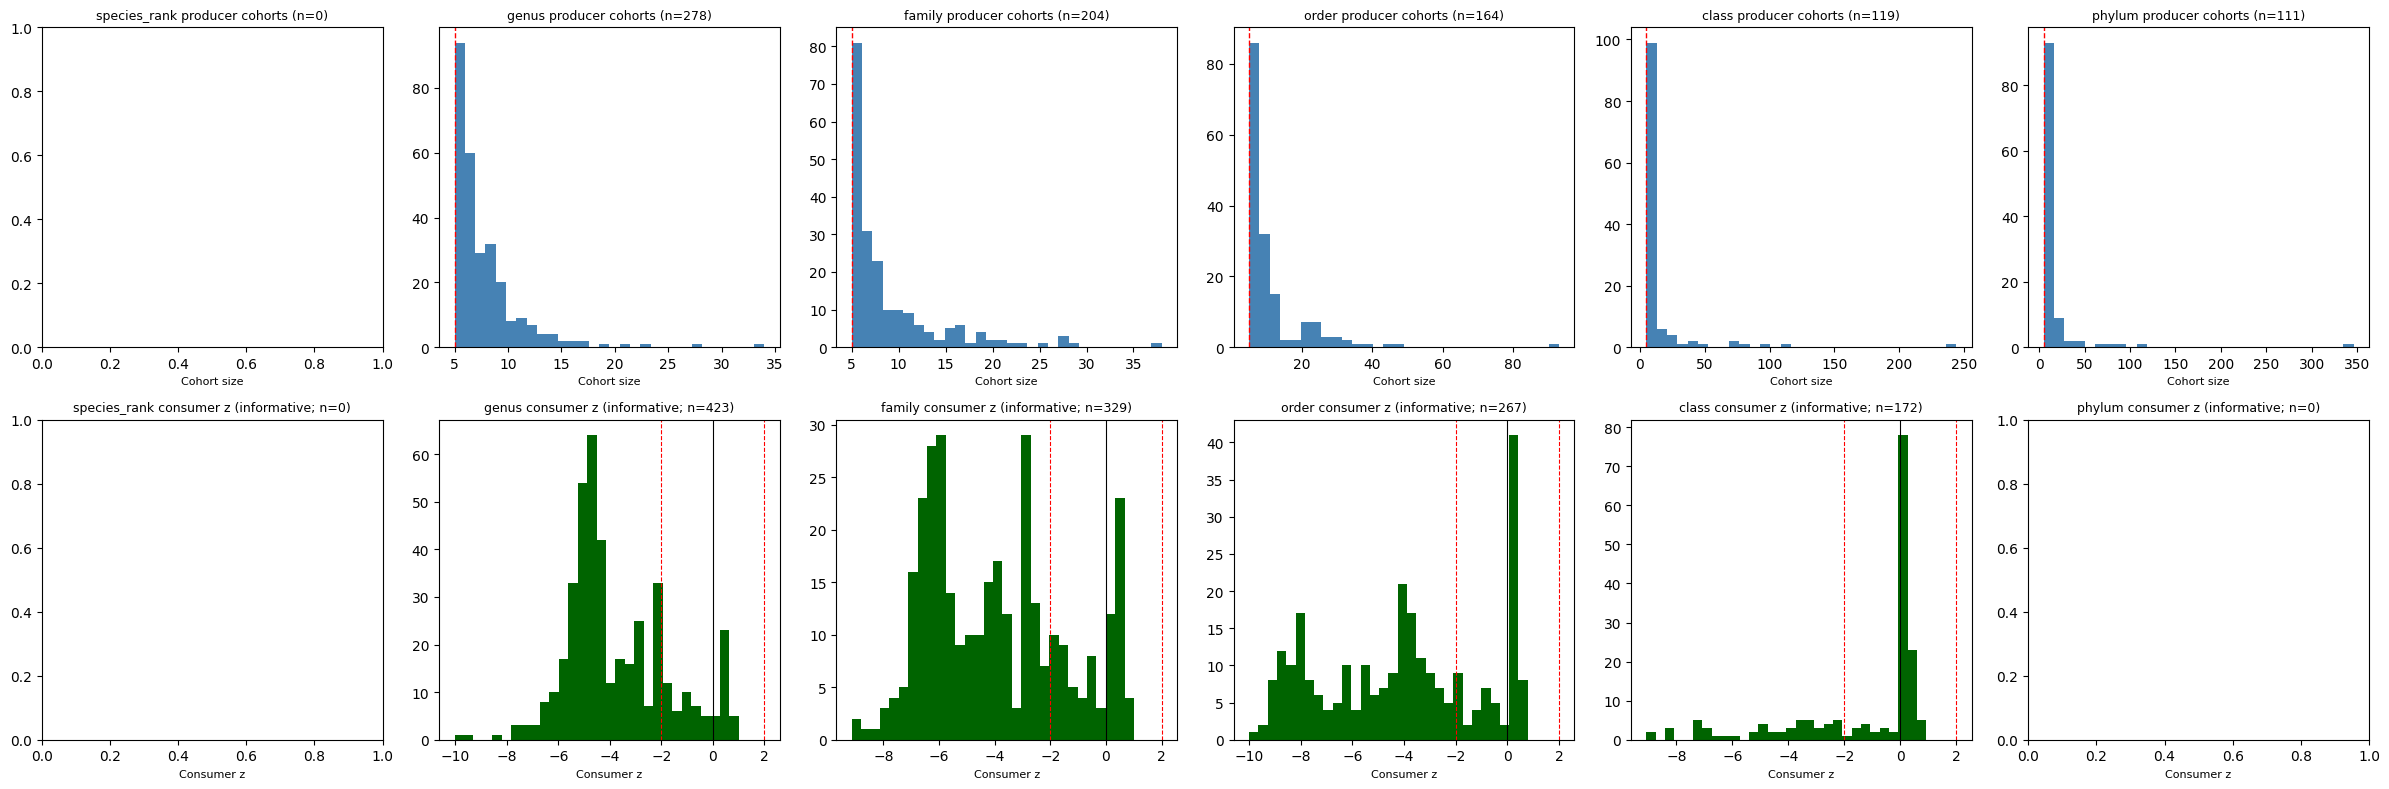

Saved figures/p1a_null_per_rank_distributions.png

Multi-rank null-model outputs materialized.


In [7]:
# Materialize per-rank lookups + global diagnostics

# Producer lookups concatenated across ranks
producer_all = pd.concat(
    [df for df in producer_lookups_by_rank.values() if len(df) > 0],
    ignore_index=True,
)
producer_all_clean = pd.DataFrame({col: producer_all[col].to_numpy() for col in producer_all.columns})
producer_path = DATA_DIR / "p1a_null_producer_lookup.parquet"
producer_all_clean.to_parquet(producer_path, index=False)
print(f"Wrote {producer_path.name}: {len(producer_all_clean):,} rows across {producer_all_clean['rank'].nunique()} ranks")

# Consumer lookups concatenated across ranks
consumer_all = pd.concat(
    [df for df in consumer_lookups_by_rank.values() if len(df) > 0],
    ignore_index=True,
)
consumer_all_clean = pd.DataFrame({col: consumer_all[col].to_numpy() for col in consumer_all.columns})
consumer_path = DATA_DIR / "p1a_null_consumer_lookup.parquet"
consumer_all_clean.to_parquet(consumer_path, index=False)
print(f"Wrote {consumer_path.name}: {len(consumer_all_clean):,} rows across {consumer_all_clean['rank'].nunique()} ranks")

# Per-rank UniRef → prevalence-bin lookup
prev_rows = []
for rank in RANKS:
    if "prevalence" not in rank_matrices[rank]:
        continue
    for u_j in range(N_UNIREFS):
        prev_rows.append({
            "rank": rank,
            "uniref50_id": uniref_ids[u_j],
            "prevalence": float(rank_matrices[rank]["prevalence"][u_j]),
            "prevalence_bin": int(rank_matrices[rank]["prevalence_bin"][u_j]),
        })
prev_df = pd.DataFrame(prev_rows)
prev_path = DATA_DIR / "p1a_uniref_prevalence_bin.tsv"
prev_df.to_csv(prev_path, sep="\t", index=False)
print(f"Wrote {prev_path.name}: {len(prev_df):,} (rank, uniref) rows")

# Diagnostics JSON
diagnostics["completed_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
with open(DATA_DIR / "p1a_null_diagnostics.json", "w") as f:
    json.dump(diagnostics, f, indent=2, default=str)
print(f"Wrote p1a_null_diagnostics.json")

# Visual: per-rank producer cohort size and consumer z distributions
fig, axes = plt.subplots(2, len(RANKS), figsize=(4*len(RANKS), 8))
for col, rank in enumerate(RANKS):
    # Top row: producer cohort sizes
    ax = axes[0, col]
    df = producer_lookups_by_rank.get(rank, pd.DataFrame())
    if len(df) > 0:
        ax.hist(df["cohort_size"], bins=30, color="steelblue")
        ax.axvline(5, color="red", ls="--", lw=1)
    ax.set_title(f"{rank} producer cohorts (n={len(df)})", fontsize=9)
    ax.set_xlabel("Cohort size", fontsize=8)

    # Bottom row: consumer z-score
    ax = axes[1, col]
    df = consumer_lookups_by_rank.get(rank, pd.DataFrame())
    if len(df) > 0:
        informative = df[df["n_clades_with"] >= 3]
        if len(informative) > 0:
            ax.hist(informative["consumer_z"], bins=30, color="darkgreen")
            ax.axvline(0, color="black", lw=0.8)
            ax.axvline(2, color="red", ls="--", lw=0.8)
            ax.axvline(-2, color="red", ls="--", lw=0.8)
    ax.set_title(f"{rank} consumer z (informative; n={len(df[df['n_clades_with']>=3]) if len(df)>0 else 0})", fontsize=9)
    ax.set_xlabel("Consumer z", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "p1a_null_per_rank_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figures/p1a_null_per_rank_distributions.png")

print("\nMulti-rank null-model outputs materialized.")

## Summary

Null model machinery is calibrated and materialized. Outputs:

- **`p1a_null_producer_lookup.parquet`** — per-(species, prevalence-bin) cohort moments for closed-form producer z-scoring at NB03
- **`p1a_null_consumer_lookup.parquet`** — per-UniRef50 observed phylum-dispersion + null mean / std from P=1,000 permutations + computed consumer z-score
- **`p1a_uniref_prevalence_bin.tsv`** — UniRef → prevalence + bin assignment lookup
- **`p1a_null_diagnostics.json`** — calibration log

Three sanity figures saved to `figures/`. NB03 will:

1. Compute producer z-scores per (species, UniRef50) using the producer lookup
2. Use the consumer z-scores already computed here
3. Validate negative controls (ribosomal / tRNA-synth / RNAP must be on-diagonal — neither high producer nor high consumer)
4. Validate positive controls (AMR + TCS HK should show high consumer z; Alm 2006 reproduction)
5. Produce the Phase 1A → Phase 1B gate decision (NB04 follows up on this if recalibration is needed)

## Notes for NB03

**Producer-score caveat**: when `cohort_size < 5` for a given (species, prevalence-bin), the producer score is undefined. NB03 should report what fraction of (species, UniRef50) presences fall into this category and exclude them from headline statistics.

**Consumer-score caveat**: phylum_dispersion is bounded in [0, 1]. UniRefs present in only 1 species have observed_dispersion = 1.0 trivially; their consumer_z is uninformative. NB03 should filter to UniRefs present in ≥3 species before reporting headline consumer-score statistics.

**Paralog fallback**: ~20 % of presence rows used `n_gene_clusters` instead of `n_uniref90_present`. NB03 should compute headline producer scores both ways (with and without fallback) and report the difference.